In [1]:
import numpy as np
import matplotlib.pyplot as plt
import netCDF4
import xarray as xr
from netCDF4 import Dataset
import seaborn as sns
import pandas as pd
import pickle
import cartopy.crs as ccrs
import cartopy.feature as cf
import windrose
from windrose import WindroseAxes
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.ticker as mticker
from cartopy.mpl.ticker import (LongitudeFormatter, LatitudeFormatter,
                                LatitudeLocator)
import matplotlib.cm as cm



import dask
import dask.dataframe as dd
from dask.diagnostics import ProgressBar
import function_trends_copy as f
#import functionBA as func
#import plotting as plot

In [2]:
# def minus_whaler(data):
#     '''creates negative and positive wind values'''
#     smaller180 = data.where(data['Wind Direction']<=180).dropna(axis = 0, how = 'all')
#     bigger180 = data.where(data['Wind Direction']>180).dropna(axis = 0, how = 'all')
#     smaller180['Wind Speed/Force'] = smaller180['Wind Speed/Force'] * -1

#     data_minus = pd.concat([smaller180, bigger180])
    
#     return data_minus

def minus_whaler(data, wind_speed_col='Wind Speed/Force'):
    '''Creates negative and positive wind values'''
    smaller180 = data.where(data['Wind Direction'] <= 180).dropna(axis=0, how='all')
    bigger180 = data.where(data['Wind Direction'] > 180).dropna(axis=0, how='all')
    
    # Adjust the wind speed/force column dynamically
    smaller180[wind_speed_col] = smaller180[wind_speed_col] * -1

    data_minus = pd.concat([smaller180, bigger180])
    
    return data_minus

def vwind_whaler(data, wind_speed_col='Wind Speed/Force'):
    '''creates negative and positive wind values'''
    north1 = data.where((data['Wind Direction']<=45)).dropna(axis = 0, how = 'all')
    north2 = data.where(data['Wind Direction']>270).dropna(axis = 0, how = 'all')
    north = pd.concat([north1, north2])
    south1 = data.where((data['Wind Direction']>45)).dropna(axis = 0, how = 'all')
    south = south1.where(data['Wind Direction']<=270).dropna(axis = 0, how = 'all')
#     south2 = data.where(data['Wind Direction']<=270).dropna(axis = 0, how = 'all')
    
#     south = pd.concat([south1,south2])
    north[wind_speed_col] = north[wind_speed_col] * -1

    vwind = pd.concat([north, south])
    
    return vwind

def ms_bf_conv(dar):
    '''
    **Conversion obtained via wikipedia
    
    input:
    resulting windspeed as xarray in meters per second
    
    output:
    resulting windspeed as xarray in Beaufort scale
    '''
    #converting windspeed in meters per second to Beafort scale
    darb = xr.where(dar < 0.5 , 0,
        xr.where((0.5<=dar)&(dar<=1.5),1,
                 xr.where((1.5<dar)&(dar<=3.3),2,
                         xr.where((3.3<dar)&(dar<=5.5),3,
                                 xr.where((5.5<dar)&(dar<=7.9),4,
                                         xr.where((7.9<dar)&(dar<=10.7),5,
                                                 xr.where((10.7<dar)&(dar<=13.8),6,
                                                         xr.where((13.8<dar)&(dar<=17.1),7,
                                                                 xr.where((17.1<dar)&(dar<=20.7),8,
                                                                         xr.where((20.7<dar)&(dar<=24.4),9,
                                                                                 xr.where((24.4<dar)&(dar<=28.4),10,
                                                                                         xr.where((28.4<dar)&(dar<=32.6),11,
                                                                                                 xr.where(32.6<dar,12,
                                                                                                         np.nan)))))))))))))
    return darb

def speedtoangle(uwind, vwind):
    radangle = np.arctan2(uwind, vwind)
    degangle = np.degrees(radangle)
    deg360 = degangle.where(degangle.values > 0, 360 + degangle.values)
    deg360to = xr.where(deg360.values > 180, deg360 - 180, deg360 + 180)
    return deg360to

def open_model(datau, datav ,lonmin, lonmax, latmin, latmax, Pacific):
    land = xr.open_dataset('/home/neele.sander/Downloads/land.nc')
    dau = datau.sortby('lat', ascending = True)
    dav = datav.sortby('lat', ascending = True)

        
    if Pacific == True:
        dau = dau.sel(lat = slice(latmin,latmax), lon = slice(lonmin,lonmax))
#         dau2 = dau.sel(lat = slice(latmin,latmax), lon = slice(-180,lonmin), time = slice("1836-01-01","1914-12-31"))
        dav = dav.sel(lat = slice(latmin,latmax), lon = slice(lonmin,lonmax))
#         dav2 = dav.sel(lat = slice(latmin,latmax), lon = slice(-180,lonmin), time = slice("1836-01-01","1914-12-31"))
        landmaskmean = land.sel(lat = slice(latmin,latmax), lon = slice(lonmin,lonmax)).mean('time')
#         land2 = land.sel(lat = slice(latmin,latmax), lon = slice(-180,lonmin))
        
#         dau = xr.combine_by_coords([dau1,dau2])
#         dav = xr.combine_by_coords([dav1,dav2])
#         landmaskmean = xr.combine_by_coords([land1,land2]).mean('time')
#         landmaskmean = land.sel(lat = slice(latmin, latmax), lon = slice(lonmin,lonmax)).mean('time')
    elif Pacific == False:
        if np.max(dau.lon >= 181):
            dau = dau.assign_coords(lon=(((dau.lon + 180) % 360) - 180)).sortby('lon', ascending = True)

        if np.max(dav.lon >= 181):
            dav = dav.assign_coords(lon=(((dav.lon + 180) % 360) - 180)).sortby('lon', ascending = True)

        if np.max(land.lon >= 181):
            land = land.assign_coords(lon=(((land.lon + 180) % 360) - 180)).sortby('lon', ascending = True)
        
        dau = dau.sel(lat = slice(latmin, latmax), lon = slice(lonmin,lonmax))
        dav = dav.sel(lat = slice(latmin, latmax), lon = slice(lonmin,lonmax))
        landmaskmean = land.sel(lat = slice(latmin, latmax), lon = slice(lonmin,lonmax)).mean('time')
        
    dau = dau.where(landmaskmean['land'] ==0, np.nan)
    dav = dav.where(landmaskmean['land'] ==0, np.nan)
    
    #resulting wind in beaufort
    dar = np.sqrt(dau.uwnd**2 + dav.vwnd**2)
    darb = ms_bf_conv(dar).rename("speed").rename("speed")
    ## resulting angle
    deg360to = speedtoangle(dau.uwnd, dav.vwnd).rename("angle")

    ds = xr.merge([dau, dav, darb,deg360to]).mean(['nbnds']).drop_vars("time_bnds")
    
    return ds



In [3]:
data = pd.read_csv('/home/neele.sander/Downloads/Tier4_180326.csv')
data['DateTime']

0         1853-07-06 12:00:00
1         1853-07-07 12:00:00
2         1853-07-08 12:00:00
3         1853-07-09 12:00:00
4         1853-07-10 12:00:00
                 ...         
127749    1863-11-13 12:00:00
127750    1863-11-14 12:00:00
127751    1863-11-15 12:00:00
127752    1863-11-16 12:00:00
127753    1863-11-17 12:00:00
Name: DateTime, Length: 127754, dtype: object

In [4]:
#whaling data
datana = f.open_logbook('/home/neele.sander/Downloads/Tier4.csv'
               ,-180, 179, -90, 90)

dsu = xr.open_dataset('/data0/neele.sander/uwnd.10m.mon.mean.nc')
dsv = xr.open_dataset('/data0/neele.sander/vwnd.10m.mon.mean.nc')

latmin = -90
latmax = 90
lonmin = -180
lonmax = 179
data_model = open_model(dsu, dsv ,lonmin, lonmax, latmin, latmax, False) #only until 1914???


In [5]:
# #put whaling data on a lat lon grid
datana['lon_round'] = np.round(datana['lon']) 
datana['lat_round'] = np.round(datana['lat'])+90
datana['lon_round'] = np.where(datana['lon_round']<0, abs(datana['lon_round']+360), abs(datana['lon_round']))

In [6]:
np.min(datana['year'])

1826.0

In [7]:
# i actually want all whaling data
whaler_times = pd.date_range(start=np.min(datana['DateTime']), end=(pd.to_datetime(np.max(datana['DateTime']))+ pd.tseries.offsets.DateOffset(days=1)), freq='D')

In [8]:
whalingxrv = np.zeros((len(data_model.lon), len(data_model.lat), len(whaler_times)))
whalingxrv = np.where(whalingxrv==0, np.nan, np.nan)
whalingxr = whalingxrv.copy()

In [9]:
whalingxru = whalingxrv.copy()

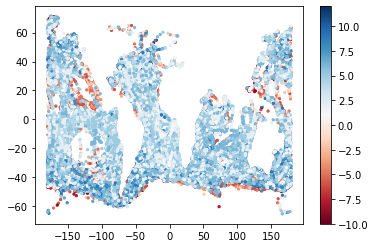

In [10]:
# datanam = minus_whaler(datana)
datau = minus_whaler(datana, wind_speed_col = 'Wind Speed/Force')
datav = vwind_whaler(datana, wind_speed_col = 'Wind Speed/Force')
b = plt.scatter(datav['lon'], datav['lat'], c = datav['Wind Speed/Force'], s= 5, cmap= 'RdBu')
plt.colorbar(b)

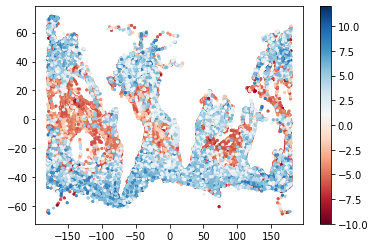

In [11]:
a = plt.scatter(datau['lon'], datau['lat'], c = datau['Wind Speed/Force'], s= 5, cmap= 'RdBu')
plt.colorbar(a)

In [12]:
#vwind
for count, value in enumerate(whaler_times):
    b = datav[datav['date']==pd.Timestamp(value)]
    if len(b) != 0:
        for i, j , k in zip(b['lon_round'].values,b['lat_round'].values, b['Wind Speed/Force'].values):
            whalingxrv[int(i),int(j),count] = k
            #print(i,j,count)

/home/neele.sander/anaconda3/lib/python3.9/site-packages/pandas/core/ops/array_ops.py:73: FutureWarning: Comparison of Timestamp with datetime.date is deprecated in order to match the standard library behavior. In a future version these will be considered non-comparable. Use 'ts == pd.Timestamp(date)' or 'ts.date() == date' instead.
  result = libops.scalar_compare(x.ravel(), y, op)


In [13]:
#uwind
for count, value in enumerate(whaler_times):
    b = datau[datau['date']==pd.Timestamp(value)]
    if len(b) != 0:
        for i, j , k in zip(b['lon_round'].values,b['lat_round'].values, b['Wind Speed/Force'].values):
            whalingxru[int(i),int(j),count] = k
            #print(i,j,count)

In [14]:
#speed
for count, value in enumerate(whaler_times):
    b = datana[datana['date']==pd.Timestamp(value)]
    if len(b) != 0:
        for i, j , k in zip(b['lon_round'].values,b['lat_round'].values, b['Wind Speed/Force'].values):
            whalingxr[int(i),int(j),count] = k
            #print(i,j,count)
            
            
            
            
            

In [15]:
whaling_vwnd = xr.DataArray(
    data=whalingxrv,
    dims=["lon", "lat", "time"],
    coords=dict(
        lon=(np.arange(0,360,1)),
        lat=(data_model.lat),
        time=whaler_times),
)

whaling_uwnd = xr.DataArray(
    data=whalingxru,
    dims=["lon", "lat", "time"],
    coords=dict(
        lon=(np.arange(0,360,1)),
        lat=(data_model.lat),
        time=whaler_times),
)

whaling_speed = xr.DataArray(
    data=whalingxr,
    dims=["lon", "lat", "time"],
    coords=dict(
        lon=(np.arange(0,360,1)),
        lat=(data_model.lat),
        time=whaler_times),
)

In [16]:
whaling_vwnd = whaling_vwnd.rename('vwnd').to_dataset()
whaling_uwnd = whaling_uwnd.rename('uwnd').to_dataset()
whaling_speed = whaling_speed.rename('speed').to_dataset()

# whaling_uwnd = xr.open_dataset('/data0/neele.sander/whaler_really_right_xr.nc')
# whaling_uwnd = whaling_uwnd.rename({'__xarray_dataarray_variable__':'uwnd'})

In [17]:
whaling_speed['uwnd'] = whaling_uwnd['uwnd']
whaling_speed['vwnd'] = whaling_vwnd['vwnd']

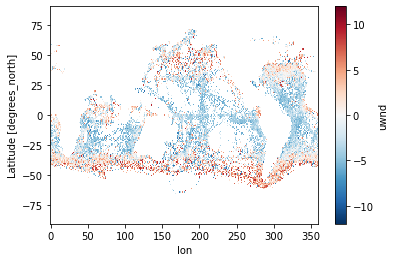

In [18]:
whaling_speed['uwnd'].mean('time').plot(x='lon')

In [19]:
#stop

NameError: name 'stop' is not defined

In [20]:

whaling_speed.to_netcdf('/data0/neele.sander/tier4whaler_uvwind_2026-03-19_xr.nc')

In [ ]:
# whaling_uwnd['speed'] = whaling_speed['speed']
# whaling_uwnd['vwnd'] = whaling_vwnd['vwnd']

In [ ]:
# whaling_uwnd.to_netcdf('/data0/neele.sander/whaler_uvwind_rigth_xr.nc')

In [ ]:
#test = xr.open_dataset('/data0/neele.sander/whaler_uvwind_xr.nc')
#test['vwnd'] = whaling_vwnd['vwnd']

In [ ]:
# whaling_vwnd['vwnd'].mean('time').plot()

In [ ]:
#test.to_netcdf('/data0/neele.sander/whaler_uvwind_rigth_xr.nc')